In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



In [2]:

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
FILE_NAME = 'diabetes_data.csv' 


In [3]:

df = pd.read_csv(FILE_NAME)
print("--- 1.2 Dataset Head ---")
print(df.head())

print("\n--- 1.3 Dataset Shape and Info ---")
print(f"Shape (Rows x Columns): {df.shape}")
df.info()

--- 1.2 Dataset Head ---
   user_id        date     weight      height  blood_glucose  \
0        1  2021-01-01  77.450712  183.993554     112.992869   
1        2  2021-01-02  67.926035  179.246337     134.219253   
2        3  2021-01-03  79.715328  170.596304     108.303203   
3        4  2021-01-04  92.845448  163.530632     127.681539   
4        5  2021-01-05  66.487699  176.982233      70.000000   

   physical_activity  diet  medication_adherence  stress_level  sleep_hours  \
0           0.000000     1                     0             1     6.342317   
1          12.792300     0                     1             2    10.658122   
2          21.727889     1                     1             0     5.997832   
3          67.753753     1                     0             1     7.958814   
4          41.131062     1                     1             0     6.774707   

   hydration_level   bmi  risk_score  
0                1  22.9   38.000000  
1                1  21.1   39.162310 

In [4]:
df['date'] = pd.to_datetime(df['date'])
numerical_cols = ['weight', 'height', 'blood_glucose', 'physical_activity', 'sleep_hours', 'bmi', 'risk_score']
categorical_cols = ['diet', 'medication_adherence', 'stress_level', 'hydration_level']

In [5]:
print("\n--- 2.1 Missing Values Detection ---")
print("Missing values per column:\n", df.isnull().sum())
print("\n--- 2.2 Duplicate Check ---")
duplicates_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates_count}")


--- 2.1 Missing Values Detection ---
Missing values per column:
 user_id                 0
date                    0
weight                  0
height                  0
blood_glucose           0
physical_activity       0
diet                    0
medication_adherence    0
stress_level            0
sleep_hours             0
hydration_level         0
bmi                     0
risk_score              0
dtype: int64

--- 2.2 Duplicate Check ---
Total Duplicate Rows: 0



--- 2.4 Outlier Detection using Boxplots ---


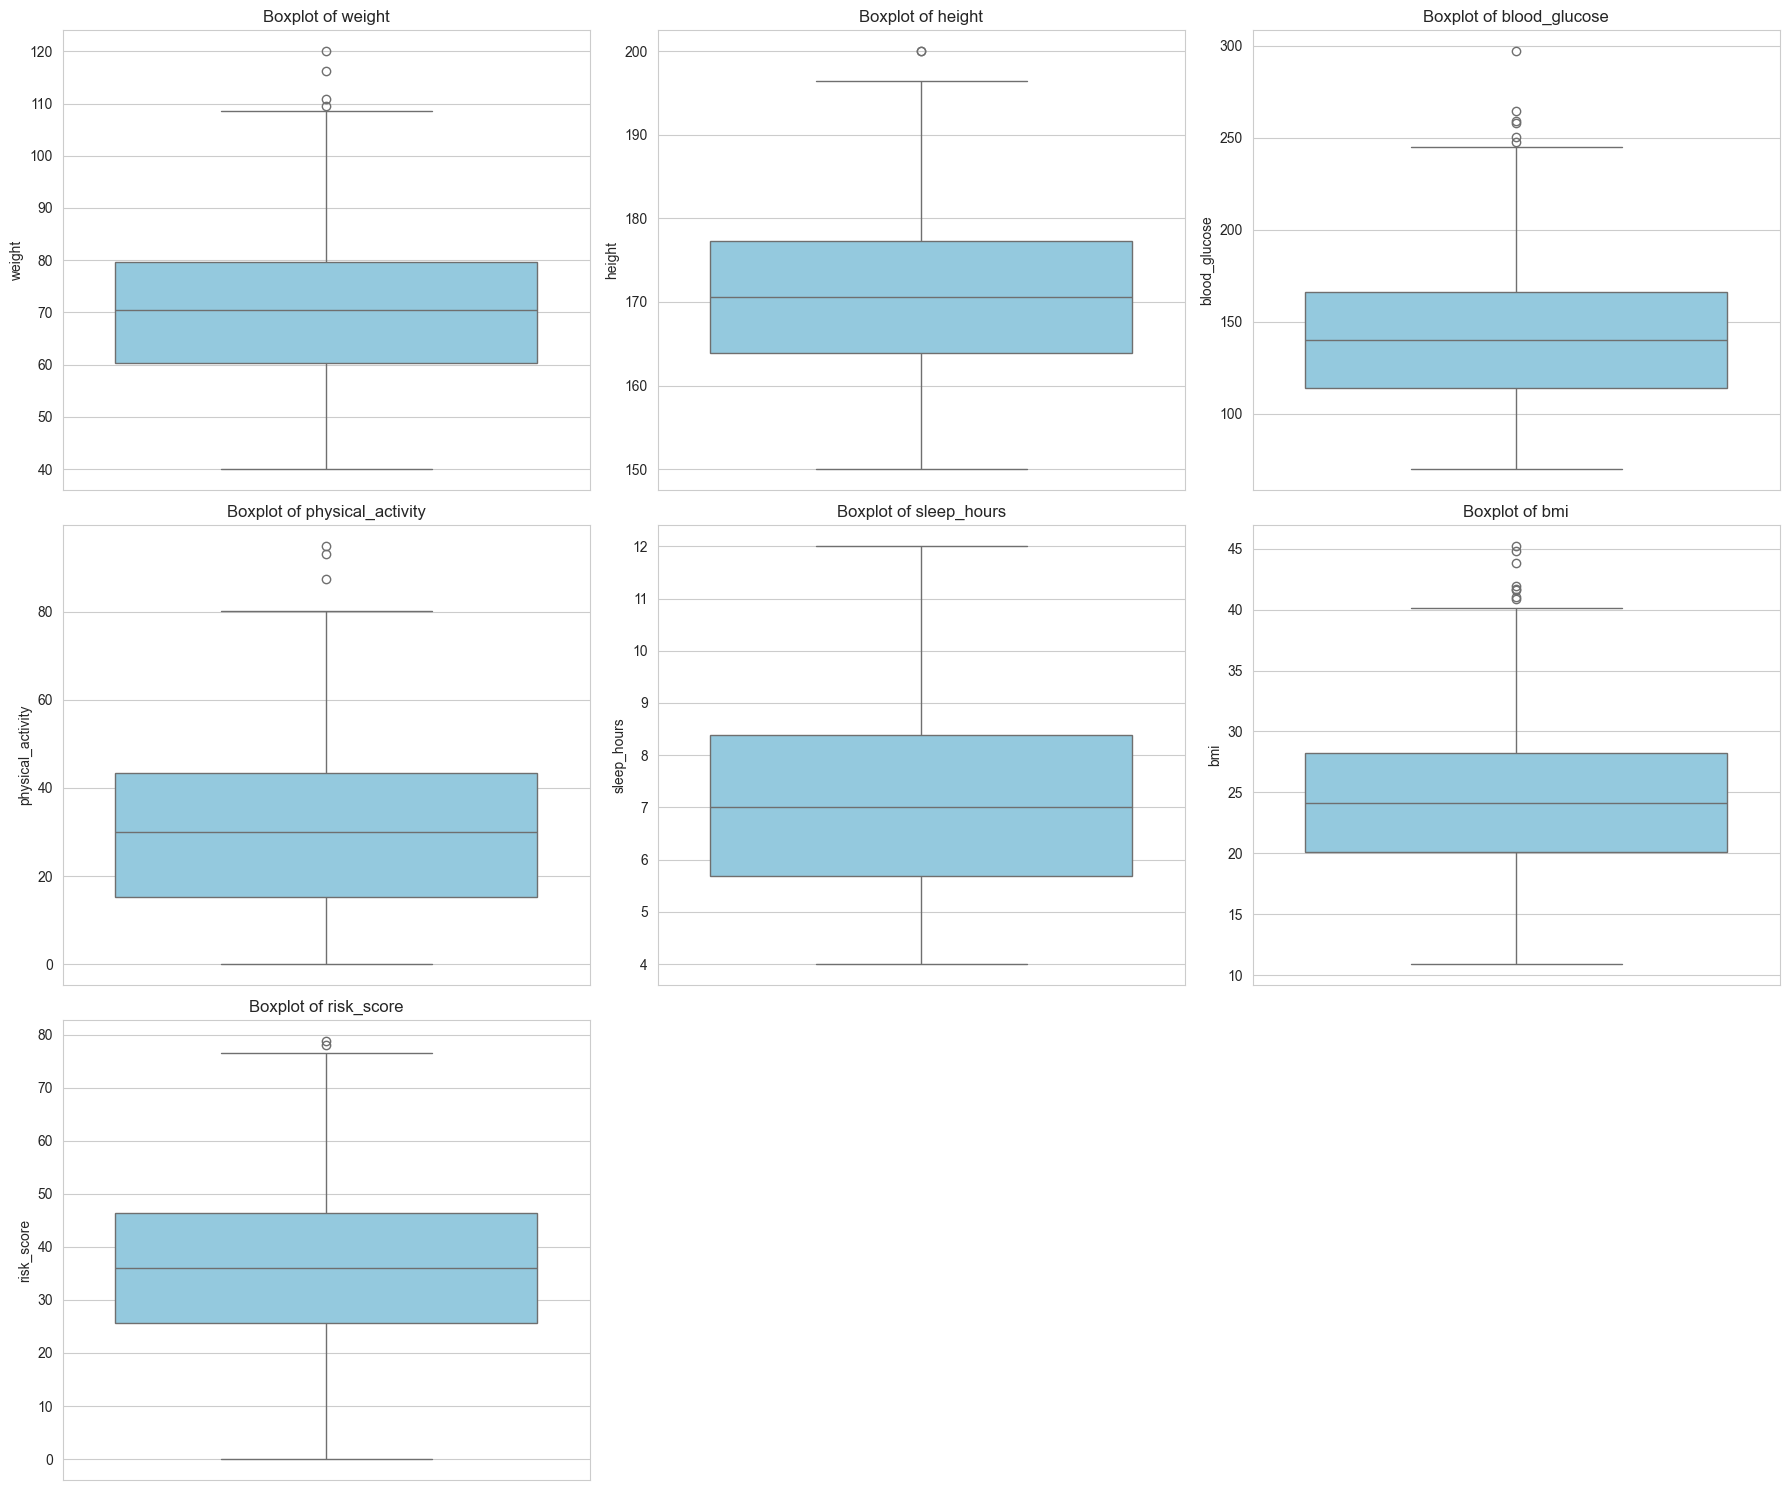

In [6]:
print("\n--- 2.4 Outlier Detection using Boxplots ---")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [7]:
print("\n--- 3.1 Descriptive Statistics for Numerical Features ---")
print(df[numerical_cols].describe().T)

print("\n--- 3.2 Value Counts for Categorical Features ---")
for col in categorical_cols:
    print(f"\n{col} Distribution:")
    print(df[col].value_counts(normalize=True) * 100)


--- 3.1 Descriptive Statistics for Numerical Features ---
                    count        mean        std    min         25%  \
weight             1000.0   70.361797  14.467165   40.0   60.286145   
height             1000.0  170.795375   9.742934  150.0  163.937583   
blood_glucose      1000.0  140.818899  38.064177   70.0  114.080015   
physical_activity  1000.0   30.294497  19.305165    0.0   15.251591   
sleep_hours        1000.0    7.076312   1.883829    4.0    5.688762   
bmi                1000.0   24.385500   5.872022   10.9   20.100000   
risk_score         1000.0   36.422120  14.898022    0.0   25.746352   

                          50%         75%         max  
weight              70.379509   79.719158  120.000000  
height             170.630771  177.288822  200.000000  
blood_glucose      139.989969  166.436613  297.049508  
physical_activity   30.003691   43.338908   94.861859  
sleep_hours          6.998834    8.391989   12.000000  
bmi                 24.100000   28.2


--- Visualizing Distributions (Histograms) ---


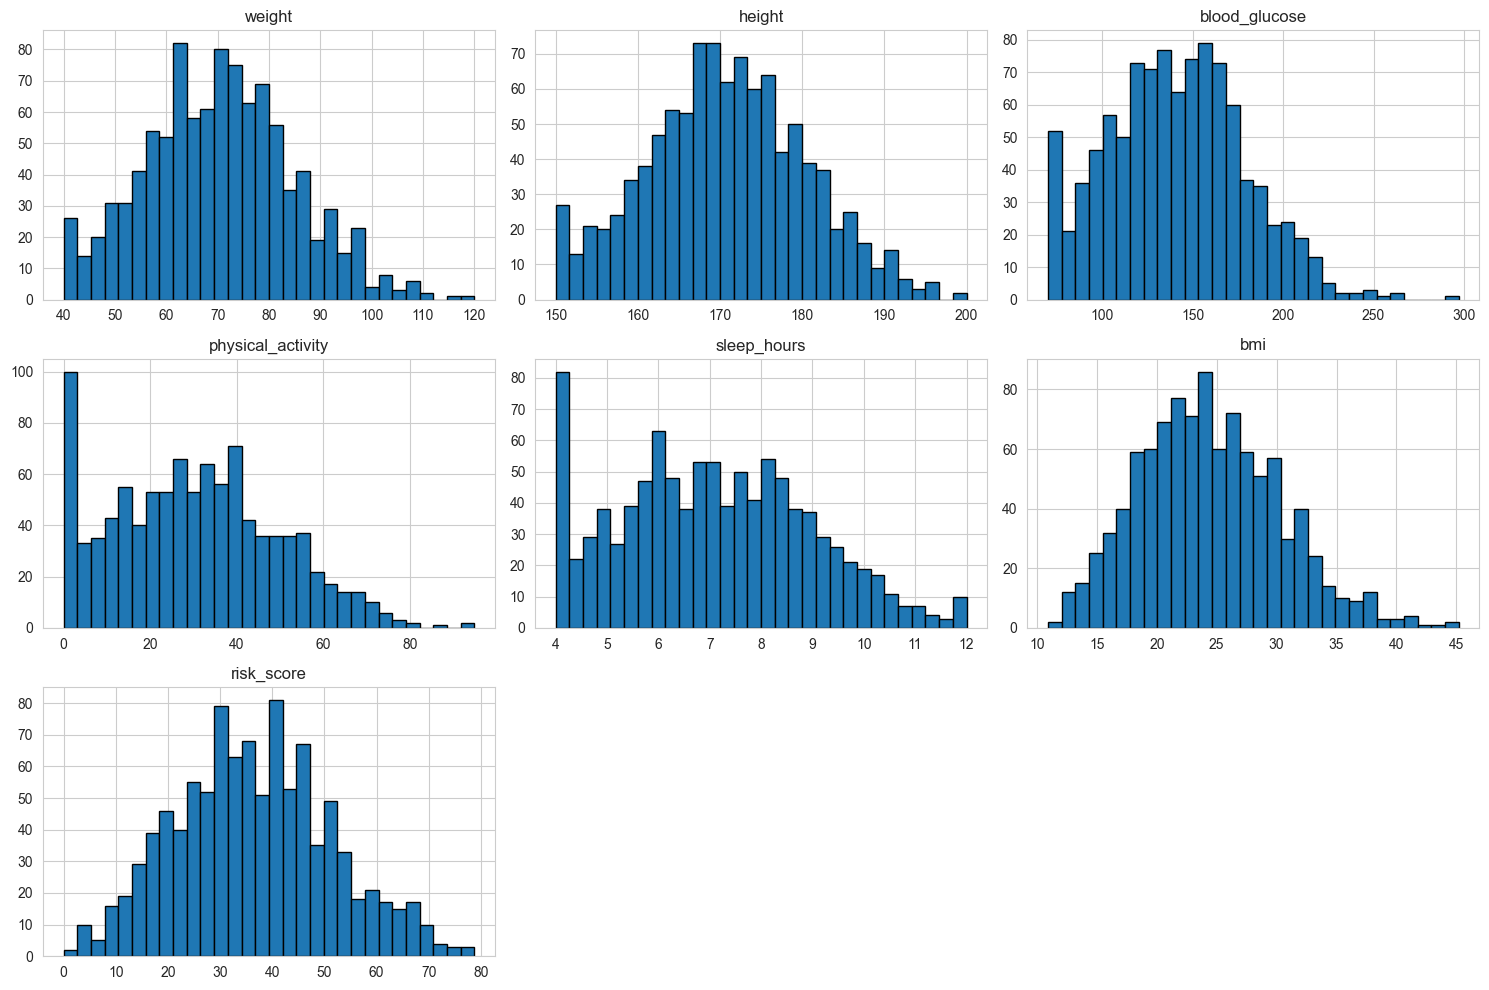

In [8]:

print("\n--- Visualizing Distributions (Histograms) ---")
df[numerical_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()



--- Visualizing Distributions (Countplots) ---


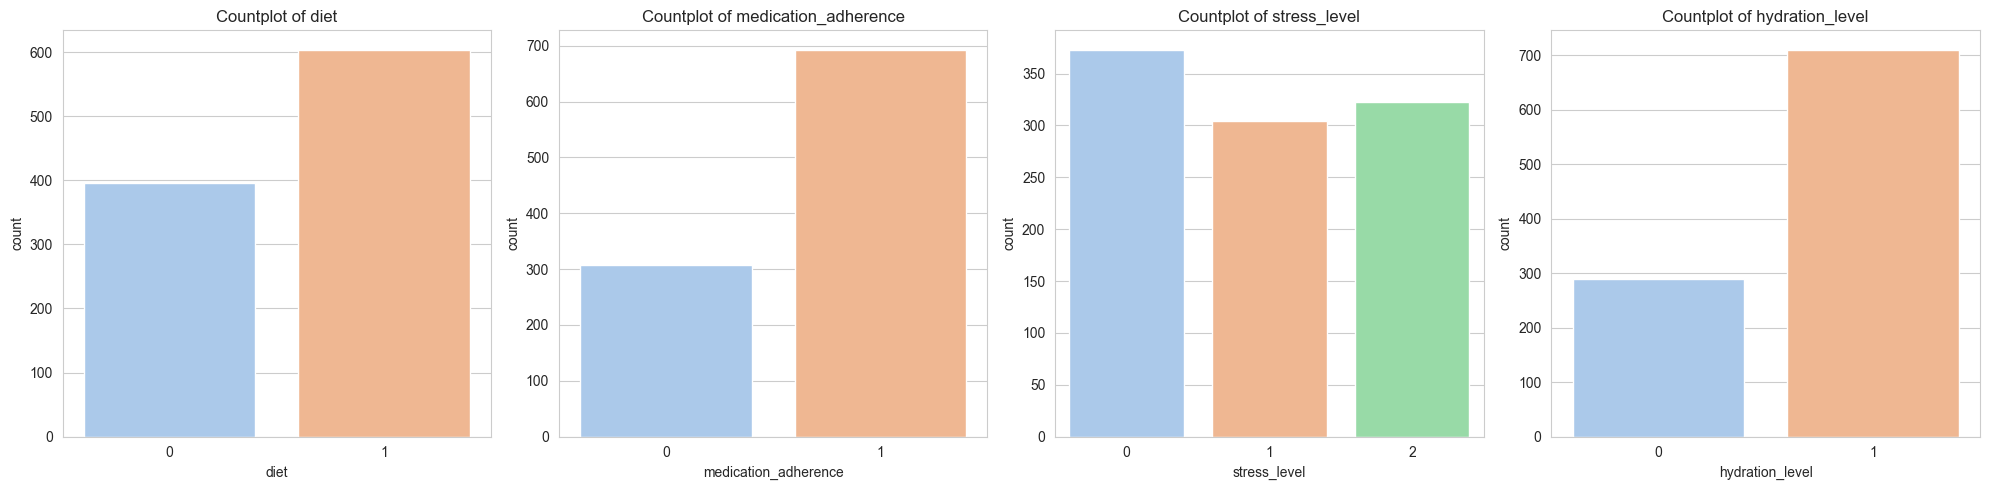

In [9]:
print("\n--- Visualizing Distributions (Countplots) ---")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], palette='pastel')
    axes[i].set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()


--- 4.1 Detailed Univariate Analysis (KDE and Boxplots) ---


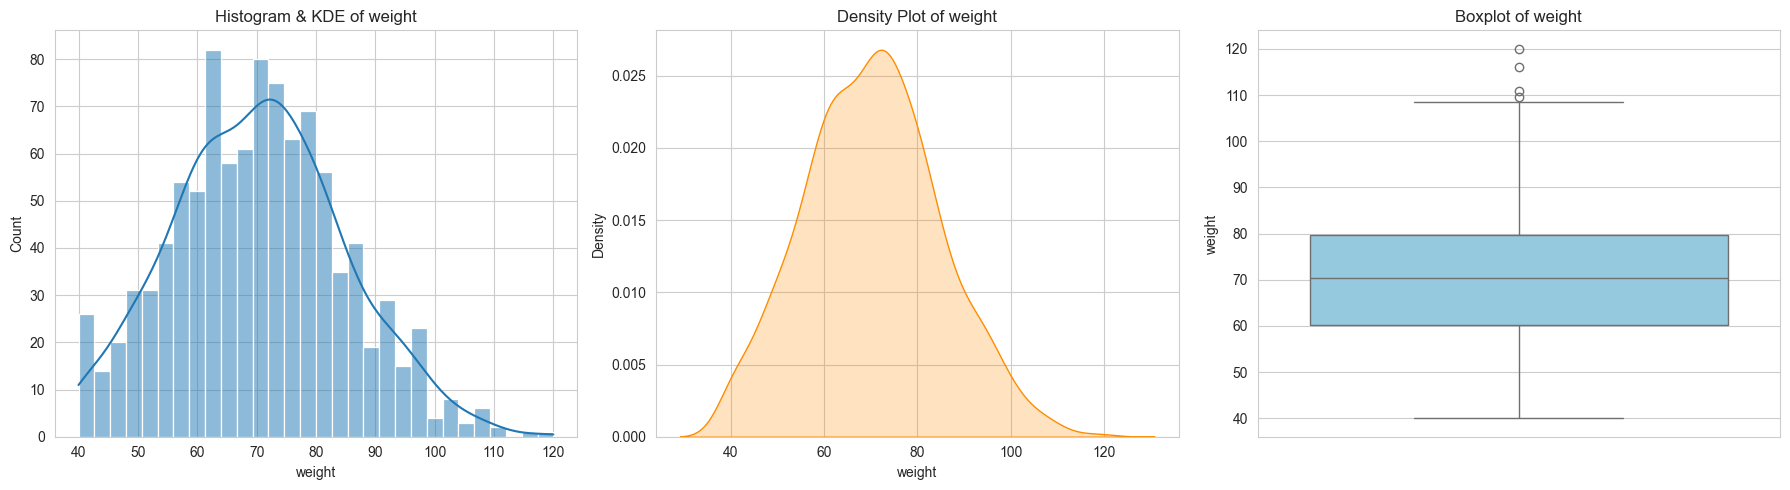

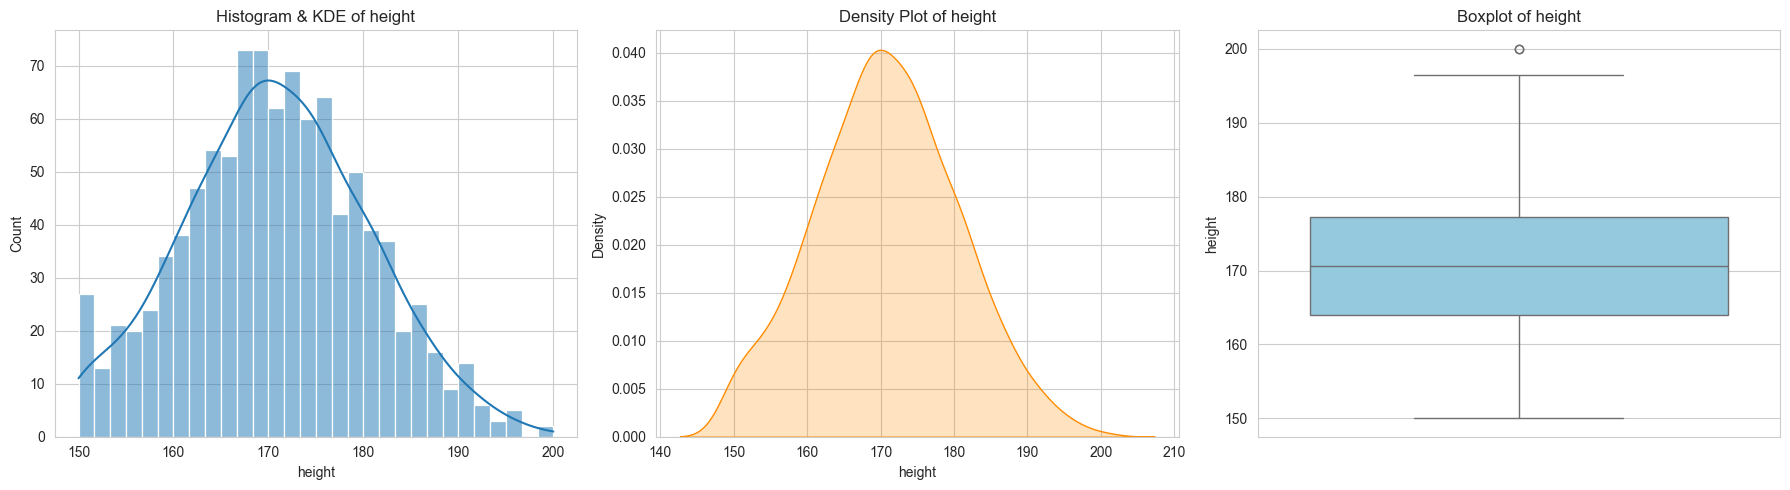

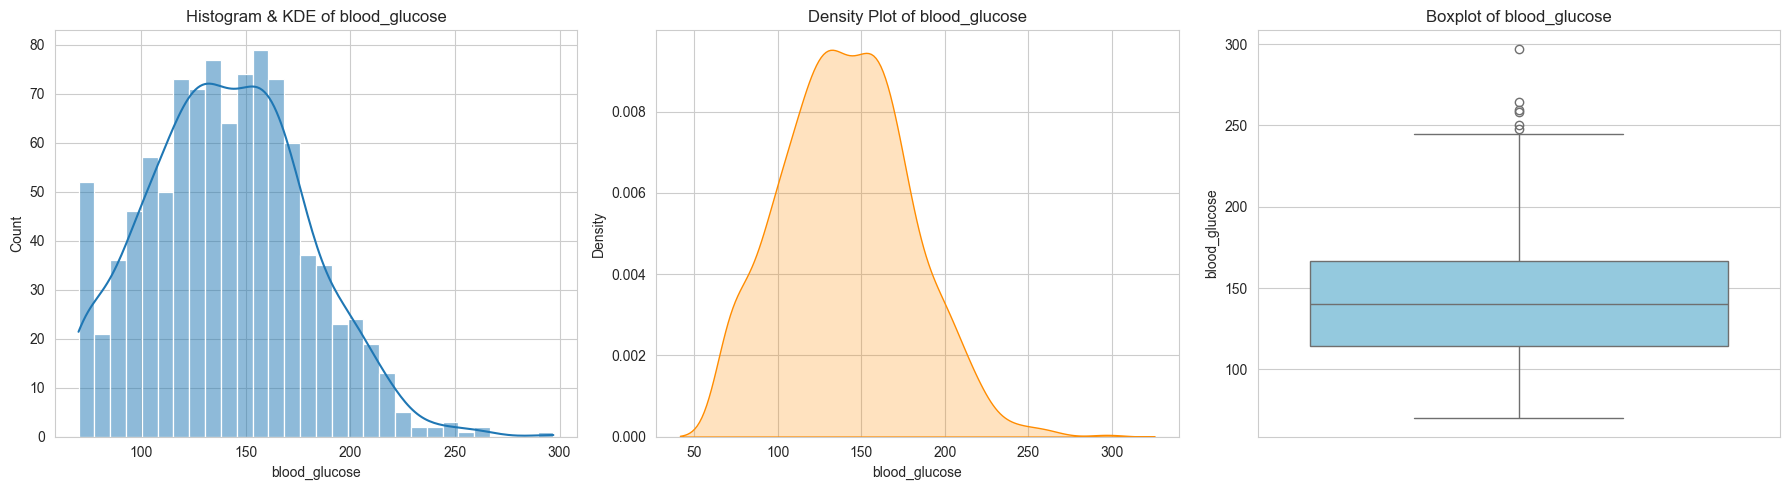

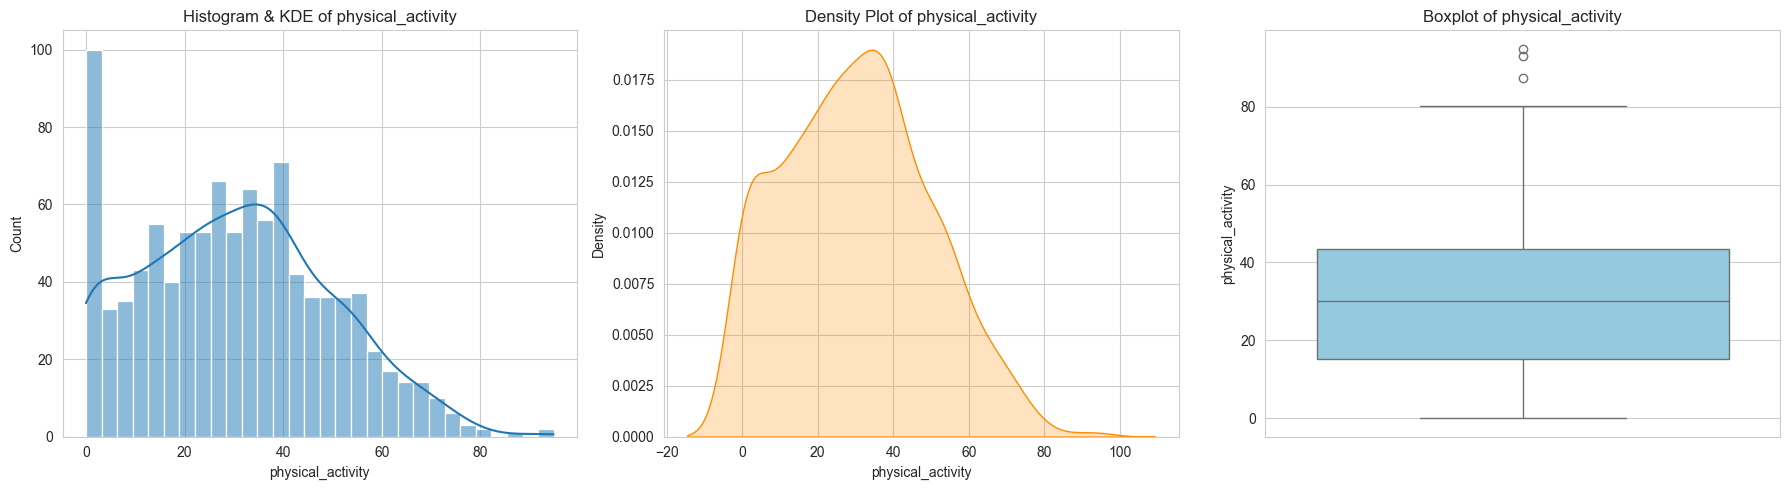

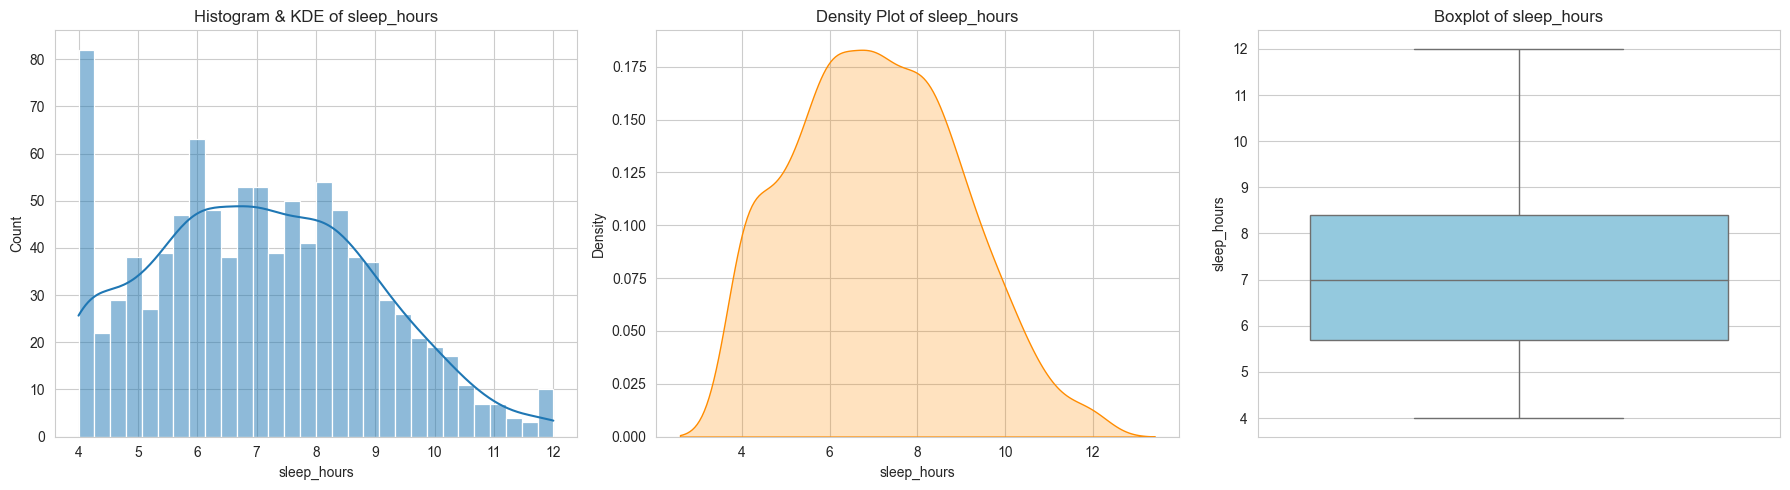

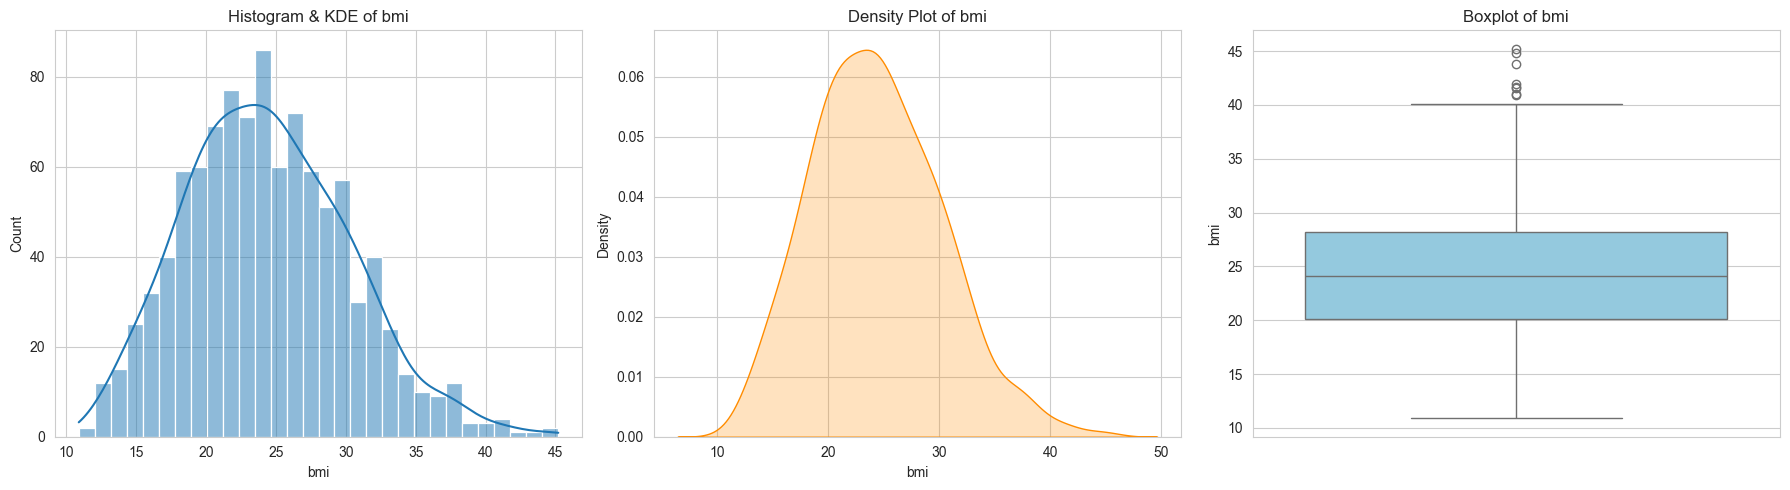

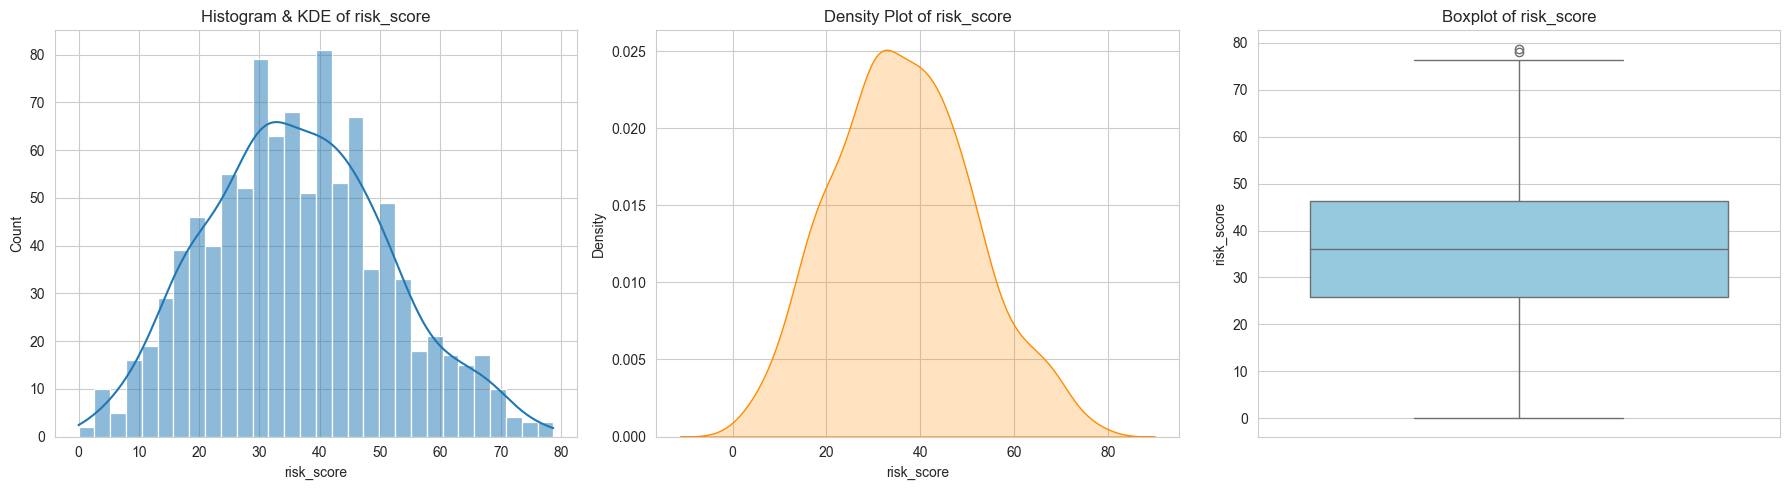

In [10]:
print("\n--- 4.1 Detailed Univariate Analysis (KDE and Boxplots) ---")
for col in numerical_cols:
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
  
    sns.histplot(df[col], bins=30, kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram & KDE of {col}')
    
   
    sns.kdeplot(df[col], fill=True, ax=ax[1], color='darkorange')
    ax[1].set_title(f'Density Plot of {col}')

  
    sns.boxplot(y=df[col], ax=ax[2], color='skyblue')
    ax[2].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()



--- 5.1 Numerical vs Numerical (Scatterplots) ---


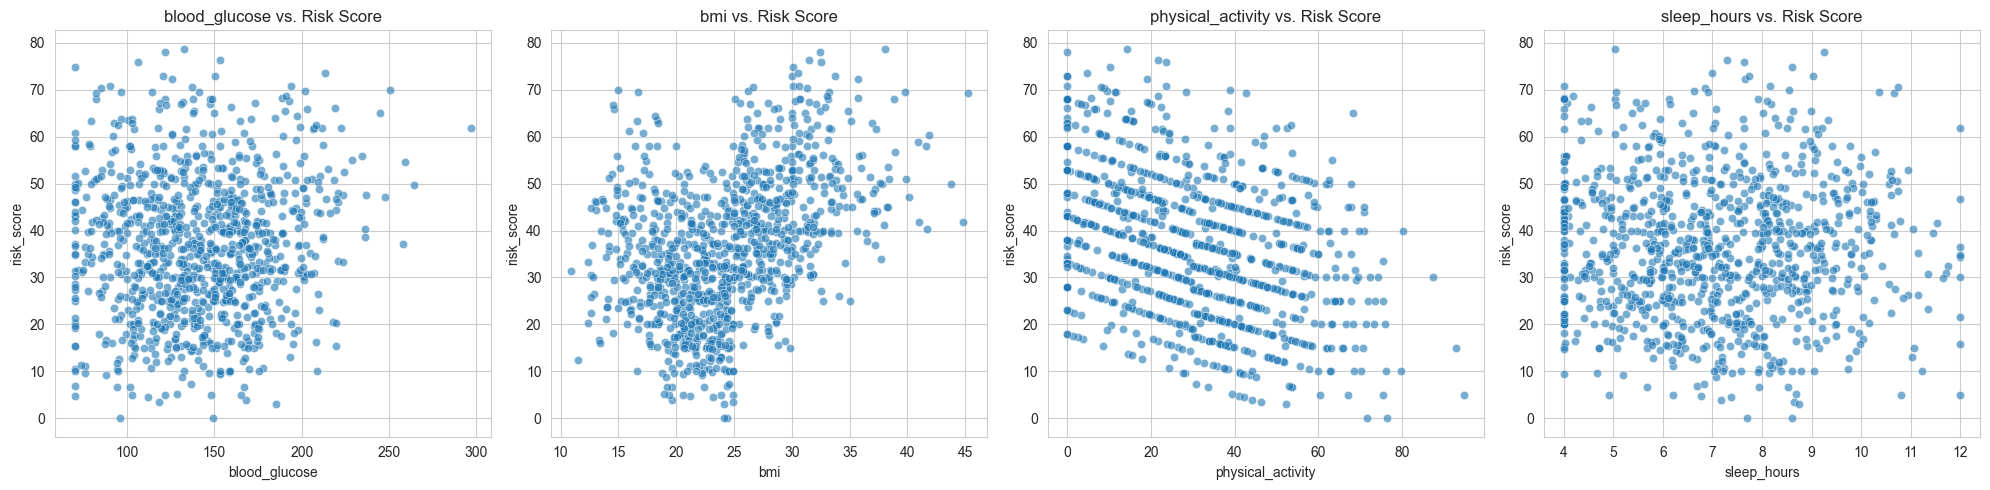

In [11]:
print("\n--- 5.1 Numerical vs Numerical (Scatterplots) ---")

key_target_vars = ['blood_glucose', 'bmi', 'physical_activity', 'sleep_hours']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(key_target_vars):
    sns.scatterplot(x=df[col], y=df['risk_score'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} vs. Risk Score')
plt.tight_layout()
plt.show()



--- 5.2 Numerical vs Categorical (Boxplots/Violin Plots) ---


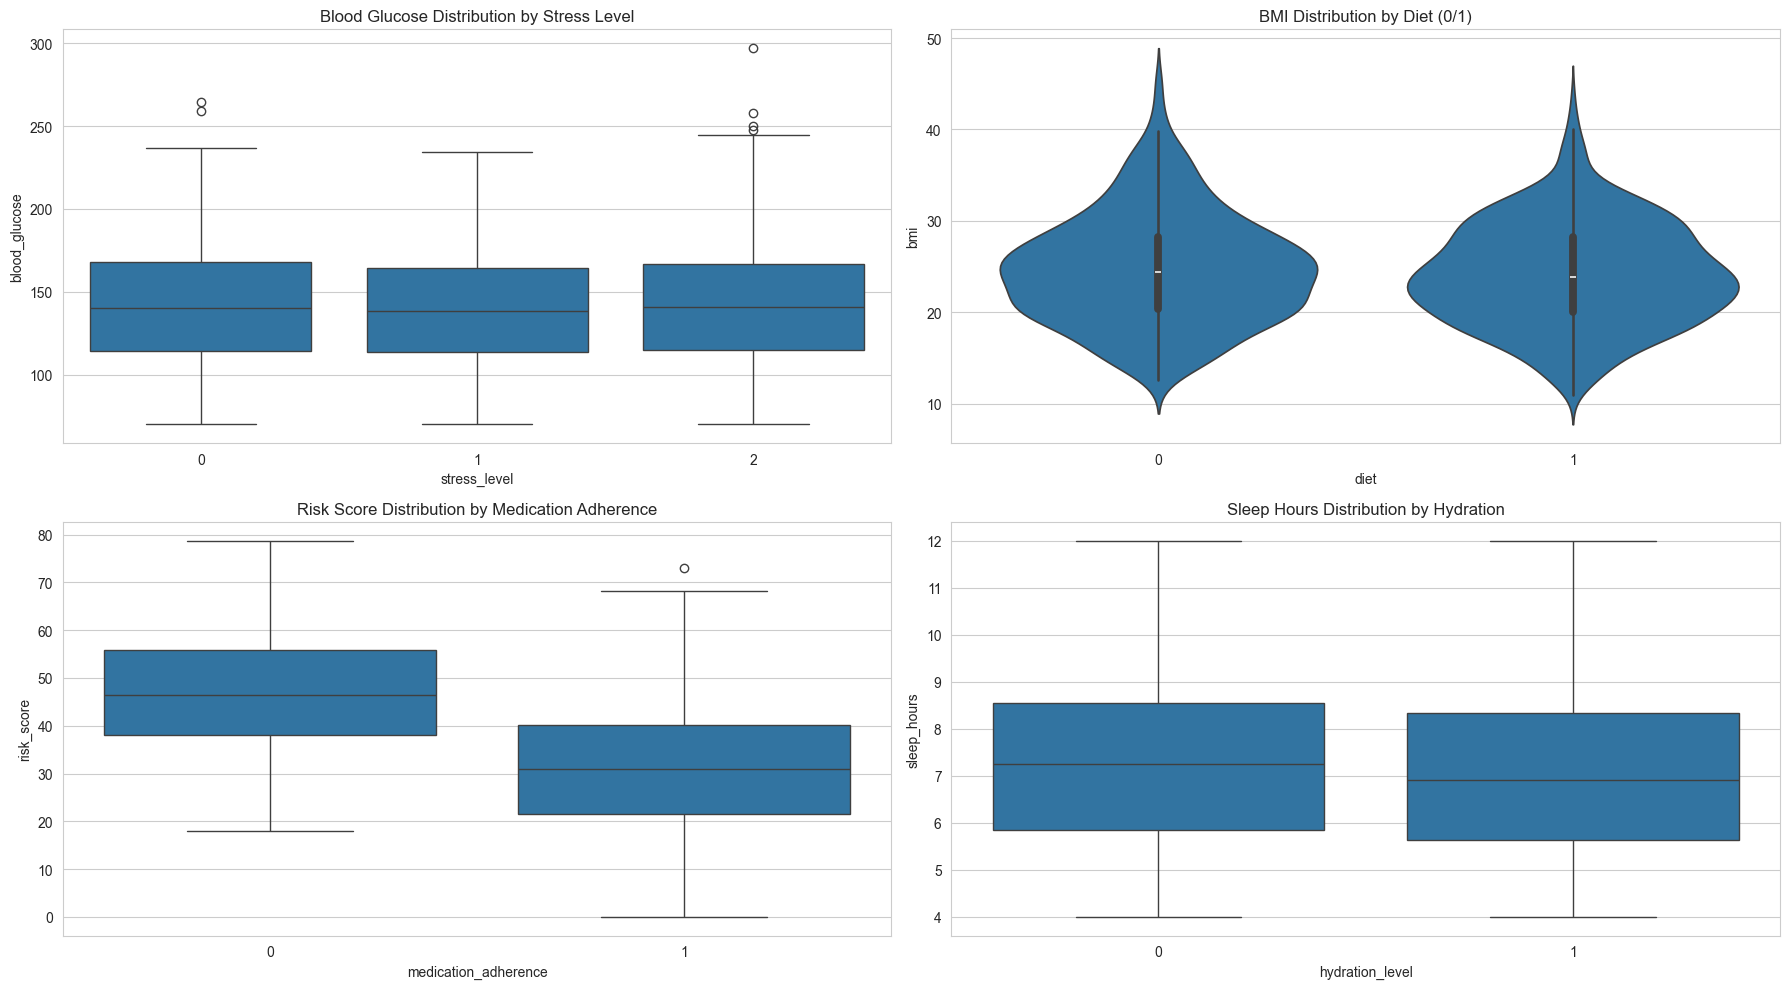

In [12]:
print("\n--- 5.2 Numerical vs Categorical (Boxplots/Violin Plots) ---")
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()


sns.boxplot(x='stress_level', y='blood_glucose', data=df, ax=axes[0])
axes[0].set_title('Blood Glucose Distribution by Stress Level')

# BMI vs Diet
sns.violinplot(x='diet', y='bmi', data=df, ax=axes[1])
axes[1].set_title('BMI Distribution by Diet (0/1)')


sns.boxplot(x='medication_adherence', y='risk_score', data=df, ax=axes[2])
axes[2].set_title('Risk Score Distribution by Medication Adherence')

sns.boxplot(x='hydration_level', y='sleep_hours', data=df, ax=axes[3])
axes[3].set_title('Sleep Hours Distribution by Hydration')

plt.tight_layout()
plt.show()




--- 5.3 Categorical vs Categorical (Crosstab Heatmap) ---


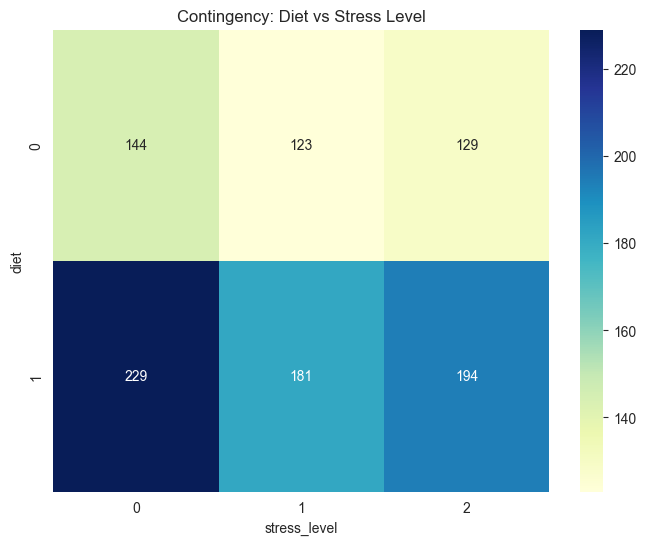

In [13]:
print("\n--- 5.3 Categorical vs Categorical (Crosstab Heatmap) ---")

crosstab_data = pd.crosstab(df['diet'], df['stress_level'])
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Contingency: Diet vs Stress Level')
plt.show()


--- 6.1 & 6.2 Correlation Heatmap (Pearson) ---


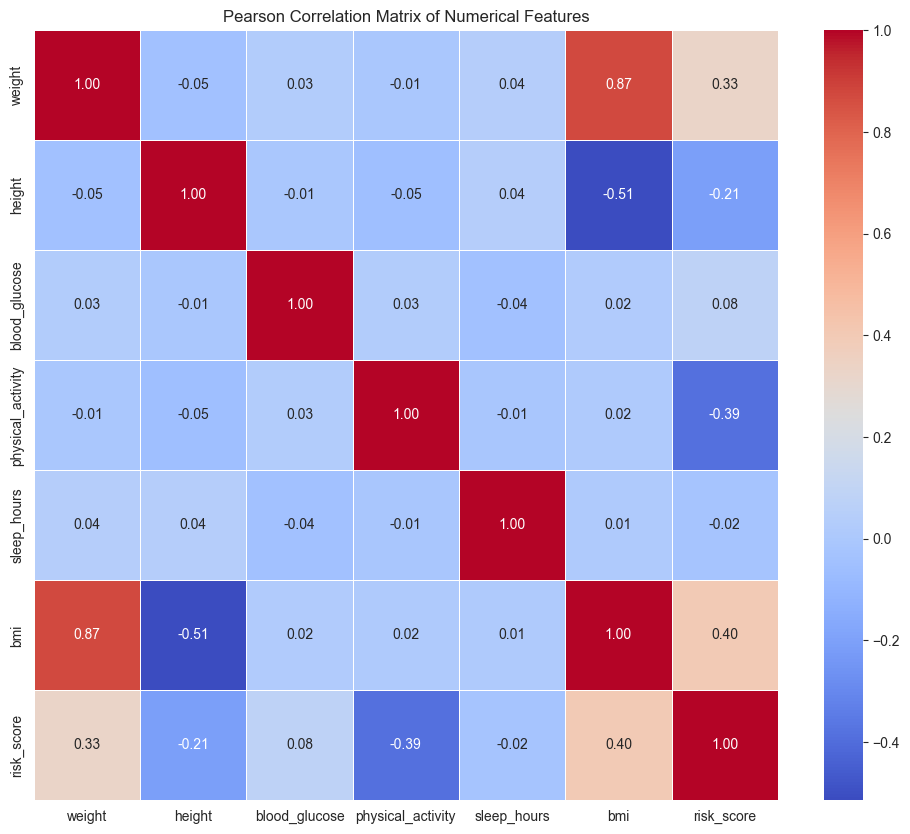

In [14]:
print("\n--- 6.1 & 6.2 Correlation Heatmap (Pearson) ---")
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

